# Revenue Driver Analysis

**Objective**

Two revenue patterns were identified in the sales data and are investigated:
1. A discrete spike in the week ending 25 September 2011
2. A sustained upward trend in revenue throughout the year


**Key Outputs**

*Revenue Spike — Week Ending 25 September 2011*

Revenue in the week ending 25 September 2011 was $179,763 above the weekly 
baseline (z-score: 2.14). Decomposition indicates the spike was driven by a 
surge in new customer and wholesaler activity, which elevated both total 
customer volume and average order value (AOV). Order frequency per customer 
did not significantly change.

New customers acquired during this week made no subsequent purchase. The spike appears to reflect a discrete one-off event rather than a structural shift in demand. This may be due to a promotional 
or clearance event that attracted first-time buyers who did not re-engage following the promotion.

If confirmed as a clearance event, consider a retention-focused follow-up 
campaign targeting the new customer cohort acquired during this period.

*Sustained Revenue Growth Trend*

A statistically significant upward trend in revenue is observed throughout the 
year. Wholesaler activity is the primary driver, contributing approximately 
$1,052 per week — around 20% of the total weekly revenue increase.

At the product category level, the three largest contributors to growth are 
Bags, Shoppers & Carry Accessories, Lighting & Candles, and Gifts, Toys & 
Novelty Items. Growth in these categories is reflected in rising AOV and 
increased customer purchasing volume. Order frequency per customer shows no 
significant trend, indicating that revenue growth is driven by higher spend 
per transaction and broader customer participation rather than increased 
purchase frequency among existing customers.

Prioritise inventory and marketing campaign in the three growth categories. 
The dominance of wholesalers in driving up trends pose a risk, changes to behaviour to 
this small group of customers will heavily influence revenue.  


**Data**

Revenue and order data are sourced from two pipelines:
- **Revenue time series** — generated from `Q_Sales` in `scripts/SQL_queries.py`
- **Order-level data** — order records joined with customer segments (from 
  `2b_rfm_analysis.ipynb`) and product categories (from `1_create_categories`), 
  used for dimensional decomposition of each driver


In [51]:
# Load packages
import pandas as pd
import numpy as np

# Import Data
IN_DIR = '../data/analysis'
sales_ts = pd.read_parquet(IN_DIR + "/sales_ts.parquet")
orders_df = pd.read_parquet(IN_DIR + "/orders.parquet")
rfm_df = pd.read_parquet(IN_DIR + "/rfm_segments.parquet")



In [52]:
# Retain columns
orders_df = orders_df[['InvoiceNo','order_date','CustomerID','StockCode','category','revenue']]

# Date
orders_df.loc[:, 'week'] = (
    orders_df['order_date'] + pd.to_timedelta(6 - orders_df['order_date'].dt.dayofweek, unit='D')
).dt.normalize()

# Merge customer segment 
orders_df = orders_df.merge(
    right = rfm_df[['CustomerID','Is_Member']],
    how='left', 
    on=['CustomerID']
    ).rename(columns={'Is_Member':'segment'})


# Recreate Time Series
weekly_ts = (
    orders_df.groupby('week')
    .agg(
        revenue=('revenue','sum'),
        customers=('CustomerID','nunique'),
        orders=('InvoiceNo', 'nunique')
    )
    .reset_index()
    .sort_values('week')
)

weekly_ts['orders_per_customer'] = weekly_ts['orders'] / weekly_ts['customers']
weekly_ts['aov']                 = weekly_ts['revenue'] / weekly_ts['orders']


## Anomaly Analysis

Based on observations in the revenue time series data, there appears to be several anomalies. We run a standard outlier and root cause analysis to determine the drivers of the outliers. 

A rolling z-score with a window of 8 weeks is sued to determine weeks in which outliers in revenue are present. An outlier is flagged if a given week's z-score exceeds two standard deviations from the 8 week rolling mean. 


In [53]:
# Generate rolling z score 
window = 8 

weekly_ts['rolling_mean'] = weekly_ts['revenue'].rolling(window).mean()
weekly_ts['rolling_std'] = weekly_ts['revenue'].rolling(window).std()
weekly_ts['z_score'] = ((weekly_ts['revenue'] - weekly_ts['rolling_mean']) 
                           / weekly_ts['rolling_std'])

# Extract anomalies 
weekly_ts['anomaly'] = weekly_ts['z_score'].abs() > 2
anomaly_weeks = weekly_ts[weekly_ts['anomaly']]

# Print results 
print(anomaly_weeks[['week','revenue', 'z_score']])



         week    revenue   z_score
41 2011-09-25  337816.75  2.137354


A single week ending on the 2011-09-25 is flagged for analysis. 


Next, we decompose the revenue into factors and dimensions to identify the root cause:
1. Revenue is decompose as follows:
$$Revenue=Customers×Orders per Customer×AOV.$$
2. Dimensions investigated are customer segments and product category. 

The next block of code contains functions that compare baseline and anomaly week across factors and dimensions. 


In [54]:
def decompose_week(orders, anomaly_week, baseline_weeks):
    
    anomaly  = orders[orders['week'] == anomaly_week]
    baseline = orders[orders['week'].isin(baseline_weeks)]
    
    metrics = {}
    for label, df in [('anomaly', anomaly), ('baseline', baseline)]:
        n_weeks = df['week'].nunique()
        metrics[label] = {
            'customers'          : df['CustomerID'].nunique() / n_weeks,
            'orders_per_customer': df['InvoiceNo'].nunique() / df['CustomerID'].nunique(),
            'aov'                : df['revenue'].mean(),
            'revenue'            : df['revenue'].sum() / n_weeks
        }
    
    return pd.DataFrame(metrics).T

# Decompose by product dimensions
def decompose_by_dimension(orders, anomaly_week, baseline_weeks, dimension):
    
    n_weeks = len(baseline_weeks)
    
    anomaly  = orders[orders['week'] == anomaly_week].groupby(dimension)['revenue'].sum()
    baseline = orders[orders['week'].isin(baseline_weeks)].groupby(dimension)['revenue'].sum()/n_weeks
    
    comparison = pd.DataFrame({
        'anomaly_revenue' : anomaly,
        'baseline_revenue': baseline
    })
    comparison['delta']   = comparison['anomaly_revenue'] - comparison['baseline_revenue']
    comparison['delta_%'] = comparison['delta'] / comparison['baseline_revenue']
    
    return comparison.sort_values('delta', ascending=False)

We first look at variation across factors between anomaly and baseline weeks.   

In [55]:
# Get weeks from z-test results
anomaly_week = anomaly_weeks['week'].iloc[0]
baseline_weeks = weekly_ts[weekly_ts['anomaly']==False]['week']

# Decompose revenue into components 
decompose_week(orders_df, anomaly_week, baseline_weeks)



,customers,orders_per_customer,aov,revenue
anomaly,436.000000,1.215596,27.077328,337816.750000
baseline,83.019231,4.924253,21.023119,177583.096923


As seen above, the number of customers engaging in orders appears to be the main driver behind the revenue increase. AOV increased by 28%, where as orders per customers saw a decrease in the anomaly week. To quantify the contribution to revenue each factor is responsible for, we apply a shapely decomposition. 


In [56]:
from itertools import permutations
import numpy as np

def shapley_decomposition(C0, F0, V0, C1, F1, V1):
    
    factors  = {'customer volume': (C0, C1), 'order frequency': (F0, F1), 'aov': (V0, V1)}
    baseline = C0 * F0 * V0
    current  = C1 * F1 * V1
    
    contributions = {k: [] for k in factors}
    
    for order in permutations(list(factors.keys())):
        vals = {k: factors[k][0] for k in factors}
        prev_revenue = baseline
        
        for factor in order:
            vals[factor] = factors[factor][1]
            new_revenue  = vals['customer volume'] * vals['order frequency'] * vals['aov']
            contributions[factor].append(new_revenue - prev_revenue)
            prev_revenue = new_revenue
    
    shapley  = {k: np.mean(v) for k, v in contributions.items()}
    residual = (current - baseline) - sum(shapley.values())
    
    rows = (
        [{'driver': 'baseline revenue', 'effect': baseline}] +
        [{'driver': k, 'effect': v} for k, v in shapley.items()] +
        [{'driver': 'residual',         'effect': residual}] +
        [{'driver': 'current revenue',  'effect': current}]
    )
    
    return pd.DataFrame(rows)

import matplotlib.pyplot as plt
import numpy as np

def plot_waterfall_matplotlib(decomposition_df):
    
    drivers = decomposition_df['driver'].tolist()
    values  = decomposition_df['effect'].tolist()
    
    running_total = 0
    bottoms = []
    for i, (driver, val) in enumerate(zip(drivers, values)):
        if driver in ['baseline revenue', 'current revenue']:
            bottoms.append(0)
        else:
            bottoms.append(running_total)
        if driver != 'current revenue':
            running_total += val
    
    colors = []
    for driver, val in zip(drivers, values):
        if driver in ['baseline revenue', 'current revenue']:
            colors.append('#378ADD')
        elif val >= 0:
            colors.append('#1D9E75')
        else:
            colors.append('#E24B4A')
    
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(drivers, values, bottom=bottoms, color=colors, width=0.5, edgecolor='white')
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + bar.get_y() + 50,
                f"${val:,.0f}",
                ha='center', va='bottom', fontsize=9)
    
    ax.set_title('Revenue change decomposition', fontsize=12)
    ax.set_ylabel('Revenue ($)')
    ax.spines[['top', 'right']].set_visible(False)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()


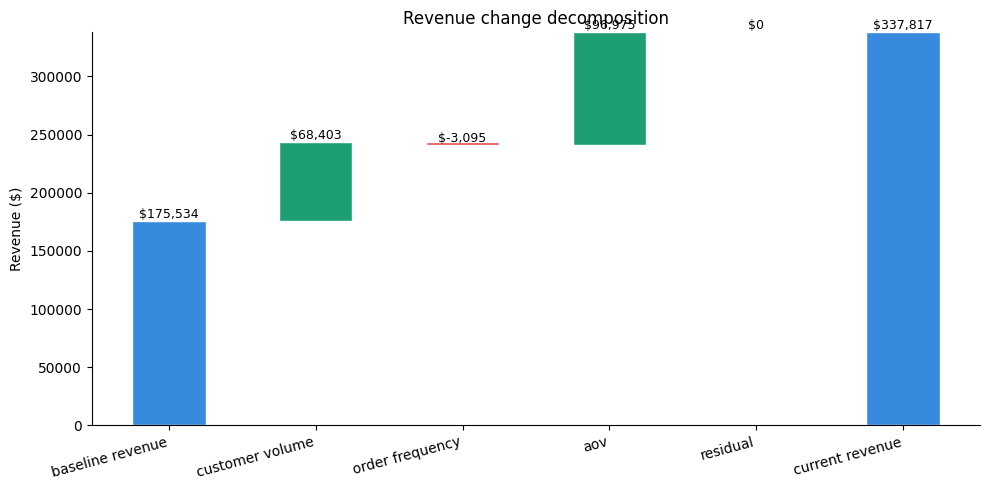

In [57]:
anomaly  = weekly_ts[weekly_ts['week'] == anomaly_week].iloc[0]
baseline = weekly_ts[weekly_ts['week'].isin(baseline_weeks)].mean()

# Baseline values
C0 = baseline['customers']
F0 = baseline['orders_per_customer']
V0 = baseline['aov']
R0 = baseline['revenue']

# Current values    F1 = anomaly['orders_per_customer']
C1 = anomaly['customers']
F1 = anomaly['orders_per_customer']
V1 = anomaly['aov']
R1 = anomaly['revenue']

results = shapley_decomposition(C0, F0, V0, C1, F1, V1)
plot_waterfall_matplotlib(results)

In terms of revenue change, increases customer volume and aov lead to the increase in revenue during the anomaly week:
- customer volume contributed to a $68,403 increase, and 
- aov contributed to a $98,975 increase.


Next we look at revenue across product category. 

In [58]:
decompose_by_dimension(
    orders=orders_df, 
    anomaly_week=anomaly_week, 
    baseline_weeks=baseline_weeks, 
    dimension='category'
    ).sort_values('delta_%',ascending = False)


,anomaly_revenue,baseline_revenue,delta,delta_%
category,,,,
Kitchenware & Beverage Accessories,26238.33,6326.422500,19911.907500,3.147420
Home Comfort & Bathroom Accessories,15462.21,3970.385192,11491.824808,2.894385
Seasonal & Christmas Decorations,12099.09,3844.861731,8254.228269,2.146821
Home Textiles & Soft Furnishings,2274.06,776.387308,1497.672692,1.929028
Home Signage & Decorative Signs,15340.03,5458.941346,9881.088654,1.810074
"Photo Frames, Albums & Paper Goods",7964.45,2925.895962,5038.554038,1.722055
Home Decor & Decorative Accessories,20842.34,8816.379231,12025.960769,1.364048
Children’s Gifts & Toys,7330.45,3308.767115,4021.682885,1.215463
Kitchenware & Party Accessories,23465.55,10820.099615,12645.450385,1.168700


The increase in revenue seems to largely stem from kitchen and home categories. Notably, Seasonal and Christmas decorations were purchased 2.2 times higher in the anomaly week compared to baseline weeks. 

In [59]:
decompose_by_dimension(
    orders=orders_df, 
    anomaly_week=anomaly_week, 
    baseline_weeks=baseline_weeks,
    dimension='segment'
    ).sort_values('delta_%',ascending = False)


,anomaly_revenue,baseline_revenue,delta,delta_%
segment,,,,
One Time Buyers,32315.43,4076.580000,28238.850000,6.927093
Active Wholesalers,158684.86,65142.883654,93541.976346,1.435951
Other,54896.20,26890.714615,28005.485385,1.041456
High Value,58418.76,32073.786538,26344.973462,0.821386
Promising,7128.86,4921.527115,2207.332885,0.448506
Champions,20500.92,18728.074231,1772.845769,0.094662
Hibernating or Lost Wholesalers,2348.99,2499.895000,-150.905000,-0.060365
At Risk,1520.91,1910.627692,-389.717692,-0.203974
Loyal,2120.20,3342.055385,-1221.855385,-0.365600


Looking across customer segments, we see that the increase is driven by 'One Time Buyers' and to a lesser degree 'Whole Salers'. To confirm this, we run a permutation test against customer segments.  


In [60]:
def test_dimension_contribution(orders, anomaly_week, dimension_col, dimension_value, n_permutations=5000):
    
    subset = orders[orders[dimension_col] == dimension_value]
    weekly_revenue = (subset.groupby('week')['revenue']
                      .sum()
                      .reset_index())
    
    observed = weekly_revenue[weekly_revenue['week'] == anomaly_week]['revenue'].values[0]
    baseline = weekly_revenue[weekly_revenue['week'] != anomaly_week]['revenue'].values
    
    observed_diff = observed - baseline.mean()
    
    null_diffs = []
    for _ in range(n_permutations):
        sample = np.random.choice(baseline, size=1)[0]
        null_diffs.append(sample - baseline.mean())
    
    p_value = np.mean(np.abs(null_diffs) >= np.abs(observed_diff))
    return {'observed_diff': observed_diff, 'p_value': p_value}

In [70]:
test_dimension_contribution(
    orders=orders_df,
    anomaly_week=anomaly_week, 
    dimension_value='One Time Buyers',
    dimension_col='segment'
    )


{'observed_diff': np.float64(22679.877272727274), 'p_value': np.float64(0.0)}

In [71]:
test_dimension_contribution(
    orders=orders_df,
    anomaly_week=anomaly_week, 
    dimension_value='Active Wholesalers',
    dimension_col='segment'
    )


{'observed_diff': np.float64(93541.97634615387), 'p_value': np.float64(0.0)}

In [62]:
test_dimension_contribution(
    orders=orders_df,
    anomaly_week=anomaly_week, 
    dimension_value='Champions',
    dimension_col='segment'
    )


{'observed_diff': np.float64(1772.845769230771), 'p_value': np.float64(0.8696)}

Therefore, we posit that the anomaly on the week ending on the 2011-09-25 is driven by an increase in customer engagement, driven by new customers who made their first purchase in that week. These customers as of date did not purchase again. The week also saw a substantial increase in revenue from 'Whole Salers'. The main purchases for the anomaly week were from  homeware and kitchen categories. 


## Trend Analysis 

To detect increases and decreases in trends we use the Mann-Kendall test, a nonparametric test specifically designed for monotonic trends in time series. 

In [63]:
# pip install pymannkendall
import pymannkendall as mk

# Get sorted weekly revenue 
in_ts = weekly_ts.sort_values(by='week', ascending=True).dropna()

# Apply test
result = mk.original_test(in_ts['revenue'])
print(f"Trend: {result.trend}, p={result.p:.4f}, slope={result.slope:.2f}")

Trend: increasing, p=0.0000, slope=3902.95


Mann-Kendall test shows a significant slope of $3902 per week. 

<Axes: xlabel='week'>

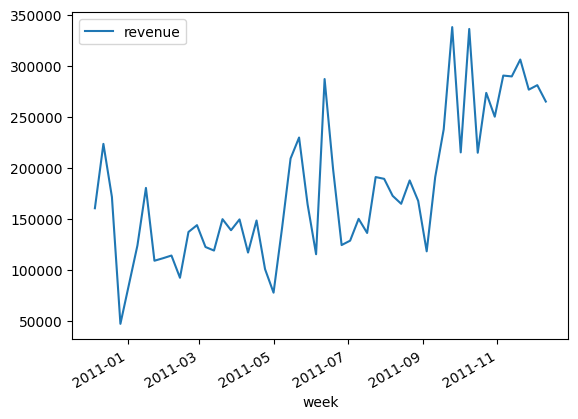

In [64]:
plot_data = weekly_ts[['week','revenue']]
plot_data = plot_data.set_index('week')

plot_data.plot()

Next we break down revenue into customers, order per customer and aov to identify the main driver of this increase. We quantify this by applying the Mann-Kendall test individually on each factor. 

In [65]:
def trend_by_factor(weekly_ts):
    
    factors = {
        'revenue'            : weekly_ts['revenue'],
        'customers'          : weekly_ts['customers'],
        'orders_per_customer': weekly_ts['orders_per_customer'],
        'aov'                : weekly_ts['aov']
    }
    
    results = []
    for factor, series in factors.items():
        result = mk.original_test(series)
        results.append({
            'factor'    : factor,
            'trend'     : result.trend,
            'slope'     : result.slope,
            'p_value'   : result.p
        })
    
    return pd.DataFrame(results)


In [66]:
trend_by_factor(weekly_ts)

,factor,trend,slope,p_value
0,revenue,increasing,3135.705865,1.753368e-07
1,customers,increasing,4.461310,1.102844e-07
2,orders_per_customer,no trend,0.000168,7.415207e-01
3,aov,increasing,2.179988,1.240651e-03


We observe significant increases in revenue due to customer volume (p-value 1.1e-7) and AOV (1.2e-3). 

Next we investigate the trend across product categories and customer segment. 

In [67]:
def weighted_trend_by_dimension(orders, dimension, min_weeks=4):
    
    total_revenue = orders['revenue'].sum()
    results = []
    
    for value in orders[dimension].unique():
        subset = (orders[orders[dimension] == value]
                  .groupby('week')['revenue']
                  .sum()
                  .reset_index()
                  .sort_values('week'))
        
        if len(subset) < min_weeks:
            print(f"Skipping {value} — only {len(subset)} weeks of data")
            continue
        
        result    = mk.original_test(subset['revenue'])
        rev_share = subset['revenue'].sum() / total_revenue
        
        results.append({
            dimension        : value,
            'trend'          : result.trend,
            'slope_per_week' : result.slope,
            'p_value'        : result.p,
            'revenue_share'  : rev_share,
            'weighted_slope' : result.slope * rev_share
        })
    
    return (pd.DataFrame(results)
              .sort_values('weighted_slope', ascending=True))

In [68]:
trend_prod_category=weighted_trend_by_dimension(
    orders=orders_df,
    dimension='category'
    ).sort_values(by='weighted_slope',ascending=False)

trend_prod_category

,category,trend,slope_per_week,p_value,revenue_share,weighted_slope
18,"Bags, Shoppers & Carry Accessories",increasing,404.859454,1.072636e-09,0.096348,39.007208
0,Lighting & Candles,increasing,259.192969,3.557146e-05,0.092327,23.930639
1,"Gifts, Toys & Novelty Items",increasing,226.332738,4.304062e-07,0.071136,16.100472
5,Kitchenware & Home Dining,increasing,121.153367,1.266765e-02,0.115044,13.937967
2,Home Decor & Decorative Accessories,increasing,202.091179,2.574478e-06,0.050072,10.119067
12,Kitchenware & Party Accessories,increasing,138.826218,3.222295e-06,0.061231,8.500456
15,"Craft Kits, Stationery & Hobby Items",increasing,129.929530,2.688680e-04,0.047618,6.186920
13,Home Decor & Storage Accessories,increasing,118.182640,4.024901e-06,0.046170,5.456436
4,"Storage, Boxes & Organisers",increasing,111.765220,1.761492e-04,0.033710,3.767603
24,Seasonal & Christmas Decorations,increasing,169.117443,2.736980e-10,0.022151,3.746111


Across all product categories, 25 of these show a significant increase. The categories
-  "Bags, Shoppers & Carry Accessories" 
- "Lighting & Candles" and 
- "Gifts, Toys & Novelty Items"

are the leading contributor to the trend increase. 

In [69]:
trend_customer_segment = weighted_trend_by_dimension(
    orders=orders_df,
    dimension='segment'
    ).sort_values(by='weighted_slope',ascending=False )

trend_customer_segment

Skipping nan — only 0 weeks of data


,segment,trend,slope_per_week,p_value,revenue_share,weighted_slope
2,Active Wholesalers,increasing,1052.678450,1.682999e-05,0.370462,389.977529
6,High Value,increasing,732.069905,1.880772e-08,0.180342,132.022736
1,Other,increasing,532.675276,8.317227e-05,0.151817,80.869169
4,Champions,increasing,299.146955,3.802438e-05,0.103881,31.075608
9,New Customers,no trend,2278.249167,2.655104e-01,0.008972,20.440052
10,One Time Buyers,no trend,578.747273,1.614407e-01,0.025522,14.770636
5,Promising,increasing,135.325849,4.663797e-07,0.027481,3.718838
8,Loyal,increasing,52.304636,1.534914e-03,0.018377,0.961202
7,At Risk,no trend,20.687500,6.940876e-02,0.010538,0.218010
0,Hibernating or Lost Wholesalers,no trend,7.972750,6.891846e-01,0.013826,0.110231


The increase in revenue is largely driven by Whole Salers, contributing three times  to revenue increase (weighted) than the second leading group. Customers in the 'High Value', 'Other' and 'Champions' groups are show significant contribution to this trend, the first two having a greater contribution that is most likely due to the larger size of these groups (high value: 15%, other: 25% and champions 4% of total customers). 
